# Tugas 2 Analisis Numerik (Revisi)
# Perhitungan Volume Kedua Lambung Kapal Katamaran

**Nama:** Nafitry Eka Arya Winanda  
**NPM:** 25083010030  
**Mata Kuliah:** Analisis Numerik

### Repositori Github : 
https://github.com/nafitryeka/25083010010_Nafitry-Eka-Arya-Winanda_Tugas-Analisis-Numerik

## 1. Deskripsi Tugas

**Soal:** hitung volume kedua lambung kapal katamaran dari gambar tampak atas dan tampak samping
(sumber gambar: *Desain dan Konstruksi Perahu Katamaran Fiberglass untuk Wisata Pancing*, ResearchGate).

**Ketentuan dari soal:**
1. Satu *dash-kosong* adalah 5 + 5 cm. Garis grid pada gambar dibentuk dari dash-kosong ini. satu kotak grid = 45 cm.
2. Lantai kapal dianggap datar (tidak ada *keel*), sehingga tampak depan semua penampang berbentuk persegi panjang.
3. Volume *reserve buoyancy* (bagian ujung buritan dan haluan di luar sekat) tidak dihitung.

**Asumsi tambahan:**
- Kedua lambung identik, sehingga $V_{\text{total}} = 2\,V_{\text{satu lambung}}$.
- Lebar lambung diukur dari tampak atas dan tinggi lambung dari tampak samping, pada tepi luar garis lambung.

**Keluaran yang diminta:** volume satu lambung dan volume kedua lambung (dalam m$^3$ dan liter).

## 2. Alur Penyelesaian

1. Import library.
2. Tetapkan skala gambar (1 kotak = 45 cm) dan posisi titik pengukuran.
3. Ukur lebar $w_i$ dan tinggi $t_i$ lambung pada tiap titik.
4. Hitung luas penampang persegi panjang $A_i = w_i \cdot t_i$.
5. Integrasikan $A(x)$ sepanjang lambung dengan metode Trapesium dan Simpson 1/3.
6. Verifikasi hasil dengan fungsi bawaan NumPy/SciPy.
7. Visualisasi dan analisis hasil.
8. Kesimpulan.

## 3. Import Library

NumPy untuk perhitungan numerik, Pandas untuk tabel, Matplotlib untuk visualisasi, dan SciPy hanya untuk verifikasi hasil.

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # mengaktifkan proyeksi 3D
from scipy.integrate import simpson

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.linestyle"] = "--"
plt.rcParams["grid.alpha"] = 0.35

print("Library berhasil diimport.")

Library berhasil diimport.


## 4. Skala dan Posisi Pengukuran

**Skala:** satu kotak grid memiliki panjang sisi

$$s = 45\ \text{cm} = 0{,}45\ \text{m}$$

**Posisi pengukuran.** Lambung dibatasi oleh dua sekat (batas *reserve buoyancy*): sekat buritan jatuh di garis grid ke-2 dan sekat haluan di garis grid ke-18.
Pengukuran dilakukan pada setiap garis grid dari ke-2 sampai ke-18, sehingga

$$n + 1 = 17\ \text{titik}, \qquad n = 16\ \text{interval}, \qquad h = s = 0{,}45\ \text{m}$$

$$L = n \cdot h = 16 \times 0{,}45 = 7{,}20\ \text{m}$$

**Konversi piksel ke cm (untuk membaca gambar).** Jarak antar garis grid pada gambar (render 200 dpi) adalah $71{,}15$ piksel, sehingga

$$1\ \text{px} = \frac{45}{71{,}15}\ \text{cm} \approx 0{,}6325\ \text{cm}$$

In [21]:
CELL_CM = 45                 # panjang sisi 1 kotak (cm)
CELL_M = CELL_CM / 100       # dalam meter
h = CELL_M                   # jarak antartitik pengukuran (m)

PX_PER_KOTAK = 71.15         # jarak antar garis grid pada gambar (piksel)
CM_PER_PX = CELL_CM / PX_PER_KOTAK

kotak = np.arange(2, 19)             # garis grid ke-2 sampai ke-18
x_m = (kotak - kotak[0]) * h         # posisi dari sekat buritan (m)
n = len(kotak) - 1                   # jumlah interval

print(f"Skala            : {CELL_CM} cm per kotak = {CELL_M:.2f} m")
print(f"Konversi gambar  : 1 px = {CM_PER_PX:.4f} cm")
print(f"Jumlah titik     : {len(kotak)}")
print(f"Jumlah interval  : {n}")
print(f"h                : {h} m")
print(f"Panjang lambung  : {x_m[-1]:.2f} m")

Skala            : 45 cm per kotak = 0.45 m
Konversi gambar  : 1 px = 0.6325 cm
Jumlah titik     : 17
Jumlah interval  : 16
h                : 0.45 m
Panjang lambung  : 7.20 m


## 5. Data Pengukuran

Lebar $w_i$ (tampak atas) dan tinggi $t_i$ (tampak samping) dibaca pada tepi luar garis lambung di setiap garis grid.
Catatan pengukuran:
- Di sekitar kotak 3 dan 4 pada tampak atas terdapat balok melintang dan penyangga diagonal. Nilai lebar di titik tersebut diambil dari tepi lambung yang bersih (tanpa balok/penyangga).
- Tinggi diukur dari garis dek sampai garis dasar. Dasar lambung naik ke arah buritan (kotak 2 sampai 4), lalu datar mulai kotak 5, sesuai asumsi lantai datar.

In [22]:
# Lebar lambung (cm) dari tampak atas, kotak 2 s.d. 18
lebar_cm = np.array([79.4, 87.3, 92.6, 94.9, 96.1, 96.1, 96.1, 96.1, 96.1,
                     96.1, 96.1, 95.8, 93.9, 90.1, 83.5, 73.7, 59.8])

# Tinggi lambung (cm) dari tampak samping, kotak 2 s.d. 18
tinggi_cm = np.array([85.4, 101.8, 113.8, 116.4, 116.4, 116.4, 116.4, 116.4, 116.4,
                      116.4, 116.4, 116.4, 116.4, 116.4, 116.4, 116.4, 116.4])

assert len(lebar_cm) == len(tinggi_cm) == len(kotak)

# Konversi ke meter
lebar_m = lebar_cm / 100
tinggi_m = tinggi_cm / 100

tabel_ukur = pd.DataFrame({
    "Kotak": kotak,
    "Posisi x (m)": x_m,
    "Lebar w (cm)": lebar_cm,
    "Tinggi t (cm)": tinggi_cm,
})
tabel_ukur

,Kotak,Posisi x (m),Lebar w (cm),Tinggi t (cm)
0,2,0.00,79.4,85.4
1,3,0.45,87.3,101.8
2,4,0.90,92.6,113.8
3,5,1.35,94.9,116.4
4,6,1.80,96.1,116.4
5,7,2.25,96.1,116.4
6,8,2.70,96.1,116.4
7,9,3.15,96.1,116.4
8,10,3.60,96.1,116.4
9,11,4.05,96.1,116.4


## 6. Dasar Perhitungan

### 6.1 Luas penampang

Karena lantai datar, penampang depan lambung berbentuk persegi panjang dengan lebar $w_i$ dan tinggi $t_i$:

$$A_i = w_i \times t_i$$

### 6.2 Volume sebagai integral luas penampang

Volume benda yang penampangnya $A(x)$ sepanjang sumbu $x$ dari $x=0$ sampai $x=L$ adalah

$$V = \int_{0}^{L} A(x)\,dx$$

Karena $A(x)$ hanya diketahui di 17 titik diskrit, integral ini didekati secara numerik.

### 6.3 Metode Trapesium (komposit)

Pada tiap interval $[x_i, x_{i+1}]$, $A(x)$ didekati garis lurus sehingga luas di bawahnya berbentuk trapesium:

$$\int_{x_i}^{x_{i+1}} A(x)\,dx \approx \frac{h}{2}\,(A_i + A_{i+1})$$

Dijumlahkan untuk semua interval:

$$V_{T} = \frac{h}{2}\left[A_0 + A_n + 2\sum_{i=1}^{n-1} A_i\right] = h\left[\frac{A_0 + A_n}{2} + \sum_{i=1}^{n-1} A_i\right]$$

Galat metode: $E_T = -\dfrac{(b-a)\,h^2}{12}\,A''(\xi)$, yaitu berorde $O(h^2)$.

### 6.4 Metode Simpson 1/3 (komposit)

Pada setiap pasang dua interval, $A(x)$ didekati polinomial kuadrat melalui tiga titik:

$$\int_{x_i}^{x_{i+2}} A(x)\,dx \approx \frac{h}{3}\,\bigl(A_i + 4A_{i+1} + A_{i+2}\bigr)$$

Dijumlahkan untuk seluruh pasangan interval (syarat: $n$ **genap**, di sini $n=16$):

$$V_{S} = \frac{h}{3}\left[A_0 + A_n + 4\sum_{i\ \text{ganjil}} A_i + 2\sum_{i\ \text{genap},\ 0<i<n} A_i\right]$$

Galat metode: $E_S = -\dfrac{(b-a)\,h^4}{180}\,A^{(4)}(\xi)$, yaitu berorde $O(h^4)$, sehingga Simpson umumnya lebih teliti daripada Trapesium.

Pola bobot Simpson 1/3 untuk $n=16$:

| indeks $i$ | 0 | 1 | 2 | 3 | $\cdots$ | 14 | 15 | 16 |
|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---:|
| bobot | 1 | 4 | 2 | 4 | $\cdots$ | 2 | 4 | 1 |

### 6.5 Volume kedua lambung dan konversi satuan

$$V_{\text{total}} = 2\,V_{\text{satu lambung}}, \qquad 1\ \text{m}^3 = 1000\ \text{liter}$$

## 7. Perhitungan

### 7.1 Luas penampang tiap titik

$A_i = w_i \times t_i$ (dalam m$^2$).

In [23]:
luas_m2 = lebar_m * tinggi_m

tabel = tabel_ukur.copy()
tabel["Luas A (m²)"] = luas_m2
tabel.round(4)

,Kotak,Posisi x (m),Lebar w (cm),Tinggi t (cm),Luas A (m²)
0,2,0.00,79.4,85.4,0.6781
1,3,0.45,87.3,101.8,0.8887
2,4,0.90,92.6,113.8,1.0538
3,5,1.35,94.9,116.4,1.1046
4,6,1.80,96.1,116.4,1.1186
5,7,2.25,96.1,116.4,1.1186
6,8,2.70,96.1,116.4,1.1186
7,9,3.15,96.1,116.4,1.1186
8,10,3.60,96.1,116.4,1.1186
9,11,4.05,96.1,116.4,1.1186


**Contoh perhitungan manual (kotak 5, indeks $i=3$):**

$$A_3 = w_3 \times t_3 = 0{,}949\ \text{m} \times 1{,}164\ \text{m} = 1{,}1046\ \text{m}^2$$

In [24]:
i = 3
print(f"Kotak {kotak[i]}: A = {lebar_m[i]:.3f} x {tinggi_m[i]:.3f} = {luas_m2[i]:.4f} m²")

Kotak 5: A = 0.949 x 1.164 = 1.1046 m²


### 7.2 Metode Trapesium

$$V_T = h\left[\frac{A_0 + A_n}{2} + \sum_{i=1}^{n-1} A_i\right]$$

In [25]:
A0, An = luas_m2[0], luas_m2[-1]
jumlah_tengah = np.sum(luas_m2[1:-1])

V_trap_1 = h * ((A0 + An) / 2 + jumlah_tengah)
V_trap_total = 2 * V_trap_1

print(f"A0                 = {A0:.4f} m²")
print(f"An                 = {An:.4f} m²")
print(f"Jumlah A tengah    = {jumlah_tengah:.4f} m²")
print(f"Volume satu lambung (Trapesium): {V_trap_1:.4f} m³")
print(f"Volume dua lambung  (Trapesium): {V_trap_total:.4f} m³")

A0                 = 0.6781 m²
An                 = 0.6961 m²
Jumlah A tengah    = 15.9640 m²
Volume satu lambung (Trapesium): 7.4930 m³
Volume dua lambung  (Trapesium): 14.9860 m³


### 7.3 Metode Simpson 1/3

$$V_S = \frac{h}{3}\left[A_0 + A_n + 4\sum_{i\ \text{ganjil}} A_i + 2\sum_{i\ \text{genap}} A_i\right]$$

Indeks mengikuti array Python (titik pertama = indeks 0). Syarat jumlah interval genap dicek lebih dulu.

In [26]:
assert n % 2 == 0, "Simpson 1/3 memerlukan jumlah interval genap."

jumlah_ganjil = np.sum(luas_m2[1:-1:2])   # i = 1, 3, 5, ..., 15 (bobot 4)
jumlah_genap  = np.sum(luas_m2[2:-1:2])   # i = 2, 4, 6, ..., 14 (bobot 2)

V_simp_1 = (h / 3) * (A0 + An + 4 * jumlah_ganjil + 2 * jumlah_genap)
V_simp_total = 2 * V_simp_1

print(f"Jumlah A indeks ganjil (bobot 4): {jumlah_ganjil:.4f} m²")
print(f"Jumlah A indeks genap  (bobot 2): {jumlah_genap:.4f} m²")
print(f"Volume satu lambung (Simpson): {V_simp_1:.4f} m³")
print(f"Volume dua lambung  (Simpson): {V_simp_total:.4f} m³")
print(f"Volume dua lambung  (Simpson): {V_simp_total*1000:.2f} liter")

Jumlah A indeks ganjil (bobot 4): 8.3709 m²
Jumlah A indeks genap  (bobot 2): 7.5931 m²
Volume satu lambung (Simpson): 7.5066 m³
Volume dua lambung  (Simpson): 15.0132 m³
Volume dua lambung  (Simpson): 15013.22 liter


### 7.4 Verifikasi dengan fungsi bawaan

Hasil perhitungan manual dibandingkan dengan `numpy.trapezoid` dan `scipy.integrate.simpson`.
Keduanya harus sama (selisih hanya galat pembulatan).

In [27]:
trapz_fn = getattr(np, "trapezoid", None) or np.trapz
V_trap_np = trapz_fn(luas_m2, x_m)
V_simp_sp = simpson(luas_m2, x=x_m)

print(f"Trapesium manual : {V_trap_1:.6f} m³ | numpy  : {V_trap_np:.6f} m³ | selisih {abs(V_trap_1-V_trap_np):.2e}")
print(f"Simpson manual   : {V_simp_1:.6f} m³ | scipy  : {V_simp_sp:.6f} m³ | selisih {abs(V_simp_1-V_simp_sp):.2e}")

Trapesium manual : 7.493004 m³ | numpy  : 7.493004 m³ | selisih 8.88e-16
Simpson manual   : 7.506608 m³ | scipy  : 7.506608 m³ | selisih 8.88e-16


### 7.5 Perbandingan kedua metode

Selisih relatif Trapesium terhadap Simpson:

$$\varepsilon = \frac{|V_S - V_T|}{V_S} \times 100\%$$

In [28]:
epsilon = abs(V_simp_total - V_trap_total) / V_simp_total * 100

hasil = pd.DataFrame({
    "Metode": ["Trapesium", "Simpson 1/3"],
    "Satu lambung (m³)": [V_trap_1, V_simp_1],
    "Dua lambung (m³)": [V_trap_total, V_simp_total],
    "Dua lambung (liter)": [V_trap_total * 1000, V_simp_total * 1000],
})
display(hasil.round(4))
print(f"Selisih relatif Trapesium vs Simpson: {epsilon:.4f} %")

,Metode,Satu lambung (m³),Dua lambung (m³),Dua lambung (liter)
0,Trapesium,7.4930,14.9860,14986.0080
1,Simpson 1/3,7.5066,15.0132,15013.2156


Selisih relatif Trapesium vs Simpson: 0.1812 %


### 7.6 Pemeriksaan kewajaran (*sanity check*)

Volume tidak boleh melebihi volume balok pembatas ($w_{\max} \times t_{\max} \times L$), dan wajar berada di atasnya sekitar 85–100% karena lambung meruncing di ujung.

In [29]:
V_balok = lebar_m.max() * tinggi_m.max() * x_m[-1]
print(f"Volume balok pembatas : {V_balok:.4f} m³")
print(f"Volume satu lambung   : {V_simp_1:.4f} m³")
print(f"Rasio isi/balok       : {V_simp_1 / V_balok * 100:.1f} %")
assert V_simp_1 < V_balok

Volume balok pembatas : 8.0539 m³
Volume satu lambung   : 7.5066 m³
Rasio isi/balok       : 93.2 %


## 8. Visualisasi

### 8.1 Tampak atas dan tampak samping lambung

Garis abu-abu vertikal menandai posisi 17 titik pengukuran.

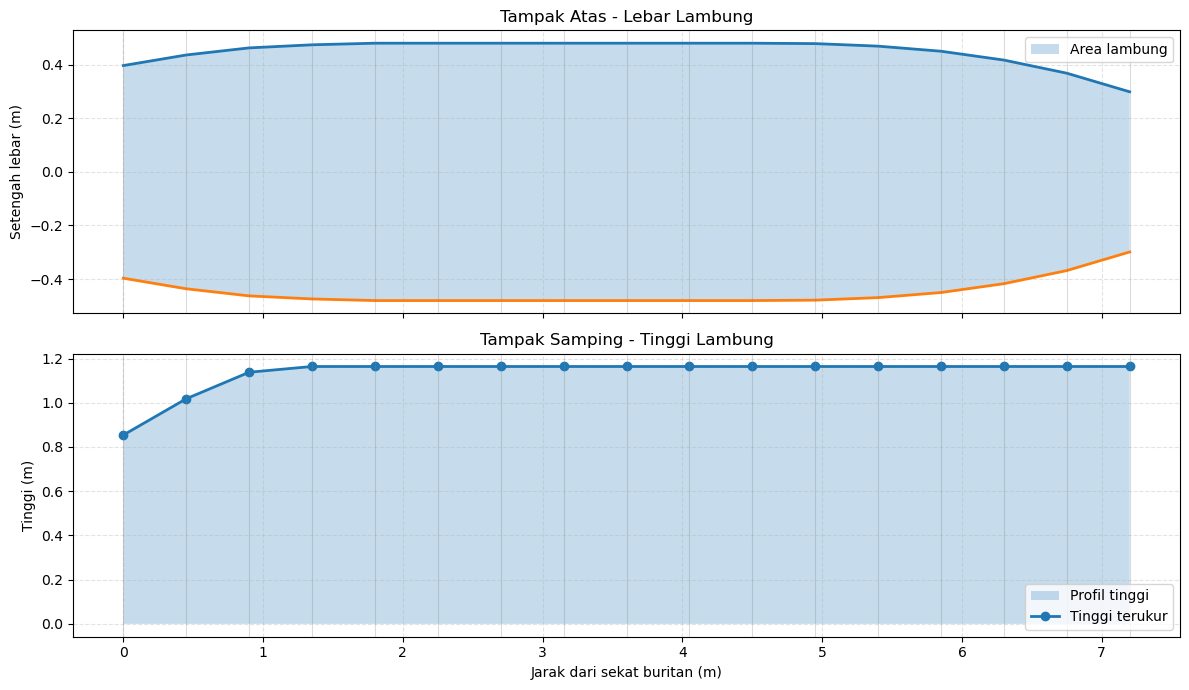

In [30]:
half_width = lebar_m / 2

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

axes[0].fill_between(x_m, -half_width, half_width, alpha=0.25, label="Area lambung")
axes[0].plot(x_m, half_width, linewidth=2)
axes[0].plot(x_m, -half_width, linewidth=2)
for xi in x_m:
    axes[0].axvline(xi, color="gray", alpha=0.28, linewidth=0.8)
axes[0].set_title("Tampak Atas - Lebar Lambung")
axes[0].set_ylabel("Setengah lebar (m)")
axes[0].legend(loc="upper right")

axes[1].fill_between(x_m, 0, tinggi_m, alpha=0.25, label="Profil tinggi")
axes[1].plot(x_m, tinggi_m, marker="o", linewidth=2, label="Tinggi terukur")
for xi in x_m:
    axes[1].axvline(xi, color="gray", alpha=0.28, linewidth=0.8)
axes[1].set_title("Tampak Samping - Tinggi Lambung")
axes[1].set_xlabel("Jarak dari sekat buritan (m)")
axes[1].set_ylabel("Tinggi (m)")
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

### 8.2 Penampang persegi panjang pada beberapa titik

Tiap persegi panjang adalah penampang depan $w_i \times t_i$ pada titik tersebut.

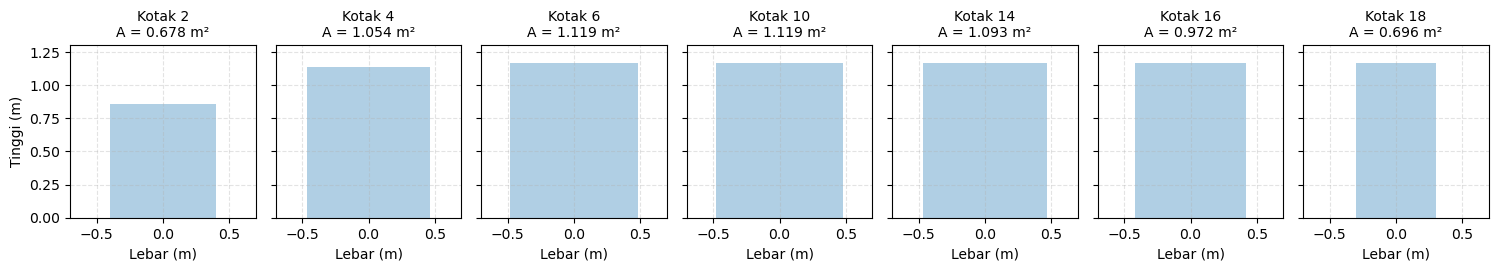

In [31]:
from matplotlib.patches import Rectangle

idx = [0, 2, 4, 8, 12, 14, 16]
fig, axes = plt.subplots(1, len(idx), figsize=(15, 3.2), sharey=True)
for ax, i in zip(axes, idx):
    ax.add_patch(Rectangle((-lebar_m[i]/2, 0), lebar_m[i], tinggi_m[i], alpha=0.35))
    ax.set_xlim(-0.7, 0.7)
    ax.set_ylim(0, 1.3)
    ax.set_aspect("equal")
    ax.set_title(f"Kotak {kotak[i]}\nA = {luas_m2[i]:.3f} m²", fontsize=10)
    ax.set_xlabel("Lebar (m)")
axes[0].set_ylabel("Tinggi (m)")
plt.tight_layout()
plt.show()

### 8.3 Luas penampang di setiap titik

Batang-batang ini adalah nilai $A_i$ yang diintegrasikan sepanjang kapal.

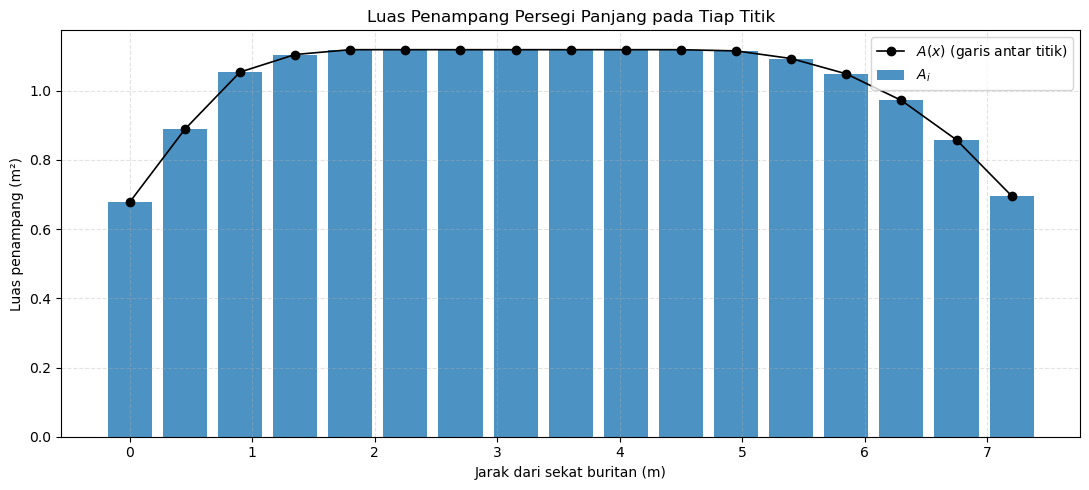

In [32]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(x_m, luas_m2, width=h * 0.8, alpha=0.8, label="$A_i$")
ax.plot(x_m, luas_m2, color="black", marker="o", linewidth=1.2, label="$A(x)$ (garis antar titik)")
ax.set_title("Luas Penampang Persegi Panjang pada Tiap Titik")
ax.set_xlabel("Jarak dari sekat buritan (m)")
ax.set_ylabel("Luas penampang (m²)")
ax.legend()
plt.tight_layout()
plt.show()

### 8.4 Pendekatan Trapesium dan Simpson pada kurva $A(x)$

Trapesium menghubungkan titik dengan garis lurus, sedangkan Simpson memakai parabola per dua interval. Volume = luas daerah di bawah kurva.

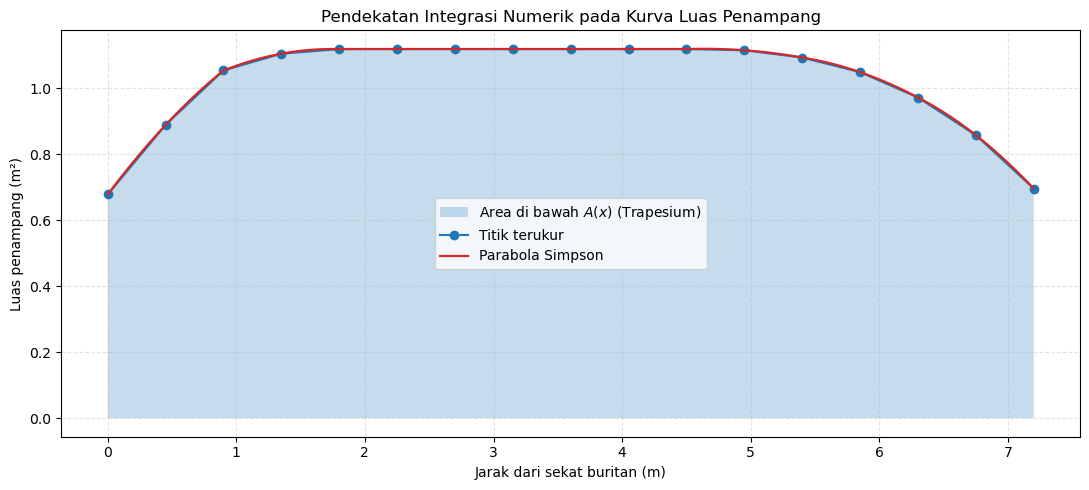

In [33]:
fig, ax = plt.subplots(figsize=(11, 5))

# Trapesium: garis lurus antar titik
ax.fill_between(x_m, luas_m2, alpha=0.25, label="Area di bawah $A(x)$ (Trapesium)")
ax.plot(x_m, luas_m2, "o-", color="tab:blue", label="Titik terukur")

# Simpson: parabola per pasangan interval
for j in range(0, n, 2):
    xs = x_m[j:j+3]
    ys = luas_m2[j:j+3]
    koef = np.polyfit(xs, ys, 2)
    xx = np.linspace(xs[0], xs[-1], 40)
    ax.plot(xx, np.polyval(koef, xx), color="tab:red", linewidth=1.6,
            label="Parabola Simpson" if j == 0 else None)

ax.set_title("Pendekatan Integrasi Numerik pada Kurva Luas Penampang")
ax.set_xlabel("Jarak dari sekat buritan (m)")
ax.set_ylabel("Luas penampang (m²)")
ax.legend()
plt.tight_layout()
plt.show()

### 8.5 Akumulasi volume sepanjang lambung

Volume kumulatif (aturan Trapesium) dari sekat buritan sampai tiap titik; nilai akhirnya adalah volume satu lambung.

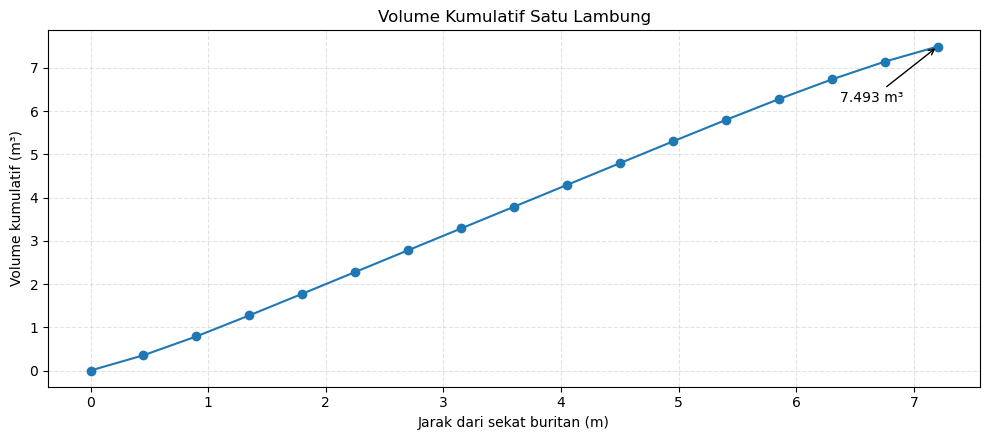

In [34]:
V_kum = np.concatenate([[0], np.cumsum(h * (luas_m2[:-1] + luas_m2[1:]) / 2)])

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(x_m, V_kum, marker="o")
ax.set_title("Volume Kumulatif Satu Lambung")
ax.set_xlabel("Jarak dari sekat buritan (m)")
ax.set_ylabel("Volume kumulatif (m³)")
ax.annotate(f"{V_kum[-1]:.3f} m³", (x_m[-1], V_kum[-1]),
            textcoords="offset points", xytext=(-70, -40), arrowprops=dict(arrowstyle="->"))
plt.tight_layout()
plt.show()

### 8.6 Perbandingan hasil kedua metode

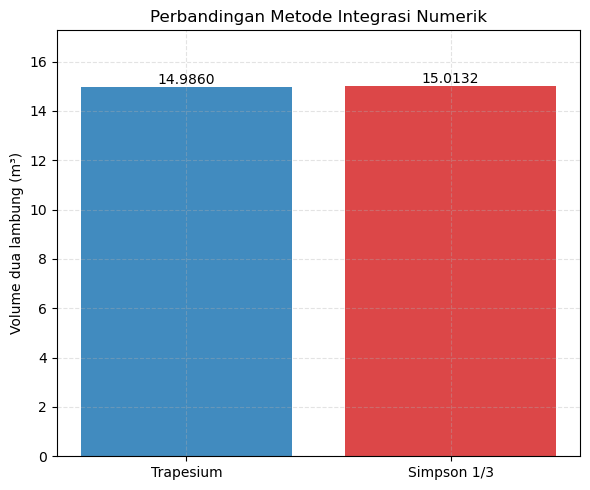

In [35]:
fig, ax = plt.subplots(figsize=(6, 5))
nama = ["Trapesium", "Simpson 1/3"]
nilai = [V_trap_total, V_simp_total]
batang = ax.bar(nama, nilai, alpha=0.85, color=["tab:blue", "tab:red"])
for b, v in zip(batang, nilai):
    ax.text(b.get_x() + b.get_width() / 2, v, f"{v:.4f}", ha="center", va="bottom")
ax.set_ylabel("Volume dua lambung (m³)")
ax.set_title("Perbandingan Metode Integrasi Numerik")
ax.set_ylim(0, max(nilai) * 1.15)
plt.tight_layout()
plt.show()

### 8.7 Model 3D konseptual dua lambung

Visualisasi skematis berdasarkan data (bukan pemindaian 3D). Penampang dibuat persegi panjang sesuai asumsi soal.

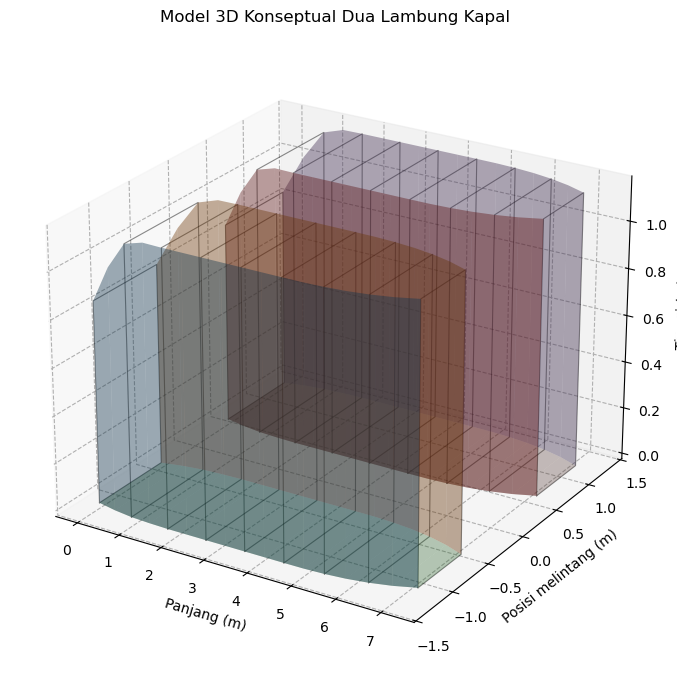

In [36]:
fig = plt.figure(figsize=(12, 7))
ax = fig.add_subplot(111, projection="3d")

for pusat_y in (-0.85, 0.85):
    for sisi in (-1, 1):
        Y = pusat_y + sisi * half_width
        # dinding samping
        X = np.column_stack([x_m, x_m])
        Yd = np.column_stack([Y, Y])
        Z = np.column_stack([np.zeros_like(x_m), tinggi_m])
        ax.plot_surface(X, Yd, Z, alpha=0.4, linewidth=0, antialiased=True)
    # lantai datar
    Xf = np.column_stack([x_m, x_m])
    Yf = np.column_stack([pusat_y - half_width, pusat_y + half_width])
    Zf = np.zeros_like(Xf)
    ax.plot_surface(Xf, Yf, Zf, alpha=0.3, linewidth=0)
    # garis penampang tiap 2 titik
    for k in range(0, len(x_m), 2):
        ax.plot([x_m[k]] * 5,
                [pusat_y - half_width[k], pusat_y + half_width[k], pusat_y + half_width[k],
                 pusat_y - half_width[k], pusat_y - half_width[k]],
                [0, 0, tinggi_m[k], tinggi_m[k], 0],
                color="black", alpha=0.45, linewidth=0.8)

ax.set_title("Model 3D Konseptual Dua Lambung Kapal")
ax.set_xlabel("Panjang (m)")
ax.set_ylabel("Posisi melintang (m)")
ax.set_zlabel("Tinggi (m)")
ax.view_init(elev=24, azim=-58)
plt.tight_layout()
plt.show()

## 9. Analisis Sensitivitas

Hasil bergantung pada pembacaan lebar dan tinggi dari gambar. Karena $A_i = w_i t_i$, galat relatif volume kira-kira sama dengan jumlah galat relatif lebar dan tinggi:

$$\frac{\Delta V}{V} \approx \frac{\Delta w}{w} + \frac{\Delta t}{t}$$

Tabel berikut menunjukkan volume dua lambung bila lebar dan tinggi sama-sama bergeser $\pm 1\%$ dan $\pm 2\%$.

In [37]:
baris = []
for p in (-2, -1, 0, 1, 2):
    f = 1 + p / 100
    A_f = (lebar_m * f) * (tinggi_m * f)
    V_f = 2 * (h / 3) * (A_f[0] + A_f[-1] + 4 * A_f[1:-1:2].sum() + 2 * A_f[2:-1:2].sum())
    baris.append([f"{p:+d}%", V_f, (V_f - V_simp_total) / V_simp_total * 100])

pd.DataFrame(baris, columns=["Pergeseran w dan t", "Volume 2 lambung (m³)", "Perubahan (%)"]).round(4)

,Pergeseran w dan t,Volume 2 lambung (m³),Perubahan (%)
0,-2%,14.4187,-3.96
1,-1%,14.7145,-1.99
2,+0%,15.0132,0.00
3,+1%,15.3150,2.01
4,+2%,15.6197,4.04


## 10. Kesimpulan

In [39]:
print("KESIMPULAN PERHITUNGAN VOLUME LAMBUNG KAPAL")
print(f"Skala gambar                   : {CELL_CM} cm per kotak")
print(f"Jumlah titik pengukuran        : {len(kotak)}")
print(f"Jumlah interval                : {n}")
print(f"Panjang lambung                : {x_m[-1]:.2f} m")
print(f"Volume satu lambung (Simpson)  : {V_simp_1:.4f} m³")
print(f"Volume dua lambung  (Simpson)  : {V_simp_total:.4f} m³ = {V_simp_total*1000:.2f} liter")
print(f"Volume dua lambung  (Trapesium): {V_trap_total:.4f} m³")
print(f"Selisih kedua metode           : {epsilon:.4f} %")
print("Catatan: hasil bergantung pada hasil ukur lebar dan tinggi dari gambar.")
print("Reserve buoyancy tidak dihitung; kedua lambung diasumsikan identik.")


KESIMPULAN PERHITUNGAN VOLUME LAMBUNG KAPAL
Skala gambar                   : 45 cm per kotak
Jumlah titik pengukuran        : 17
Jumlah interval                : 16
Panjang lambung                : 7.20 m
Volume satu lambung (Simpson)  : 7.5066 m³
Volume dua lambung  (Simpson)  : 15.0132 m³ = 15013.22 liter
Volume dua lambung  (Trapesium): 14.9860 m³
Selisih kedua metode           : 0.1812 %
Catatan: hasil bergantung pada hasil ukur lebar dan tinggi dari gambar.
Reserve buoyancy tidak dihitung; kedua lambung diasumsikan identik.


Berdasarkan integrasi numerik terhadap luas penampang persegi panjang di 17 titik (skala satu kotak 45 cm, panjang lambung 7,20 m), diperoleh:

- Volume satu lambung $\approx 7{,}51\ \text{m}^3$.
- Volume kedua lambung $\approx 15{,}01\ \text{m}^3$ ($\approx 15.013$ liter) dengan Simpson 1/3, dan $14{,}99\ \text{m}^3$ dengan Trapesium. Selisihnya hanya sekitar $0{,}18\%$.

Metode Simpson 1/3 dipakai sebagai hasil utama karena berorde galat $O(h^4)$, lebih tinggi daripada Trapesium yang $O(h^2)$.
Hasil ini masih berupa estimasi karena lebar dan tinggi dibaca manual dari gambar (galat pembacaan sekitar 2–3%), penampang dianggap persegi panjang, dan *reserve buoyancy* tidak dihitung.